一、核心库导入

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化

二、数据读取与预处理模块

In [2]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
# T:0（波周期）、H:1（波高）、Surge:2（纵荡）、Heave:4（垂荡）、Force1:8（系泊力1）
data_1 = pd.read_csv('t_1.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-277.0,-2.36,0.000849,-15.1,3.230000e-09,-0.0121,-1.980000e-09,4890.0,5070.0
1,1.1,-591.0,-30.10,-0.185000,-448.0,3.090000e-05,-0.0156,-1.650000e-05,4260.0,4680.0
2,2.1,-457.0,-112.00,1.570000,-422.0,5.970000e-04,0.0303,1.440000e-04,4320.0,4680.0
3,3.1,85.5,28.00,-0.265000,51.0,-3.080000e-04,0.0570,1.300000e-04,5580.0,4610.0
4,4.1,618.0,95.70,-2.900000,488.0,3.310000e-05,0.0352,2.270000e-04,6180.0,5040.0


In [3]:
# 提取数据的关键列：第1-7列（H、Surge、Sway、Heave、Roll、Pitch、Yaw）和第8-9列（Force1、Force2）
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

[[-2.77e+02 -2.36e+00  8.49e-04 ... -1.98e-09  4.89e+03  5.07e+03]
 [-5.91e+02 -3.01e+01 -1.85e-01 ... -1.65e-05  4.26e+03  4.68e+03]
 [-4.57e+02 -1.12e+02  1.57e+00 ...  1.44e-04  4.32e+03  4.68e+03]
 ...
 [ 3.29e+02  1.75e+02 -6.20e+00 ... -6.95e-05  6.32e+03  4.61e+03]
 [ 8.32e+02  1.92e+02 -3.20e+00 ...  4.27e-04  6.59e+03  4.96e+03]
 [ 7.99e+02  1.13e+02  1.83e+00 ...  8.30e-05  6.02e+03  5.51e+03]]
(11000, 9)


In [4]:
H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5]*1e6)
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7]*1e6)
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force2_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

三、模型定义模块
功能：定义 4 种循环神经网络模型（GRU、LSTM、BiLSTM、Bi-StatefulLSTM）和 2 种神经网络模型（Model_NN1、Model_NN），适配论文中的不同模型对比实验

1. GRU 模型

In [5]:
# GRU模型：用于时间序列预测
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

2. LSTM 模型

In [6]:

# LSTM模型：用于时间序列预测
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

3. BiLSTM 模型

In [7]:

# BiLSTM模型：双向LSTM，同时利用前向和后向序列信息
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# Bi-StatefulLSTM模型：双向有状态LSTM，适用于长序列依赖
def Model_Bi_StatefulLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(batch_size, train_X.shape[1], train_X.shape[2]),stateful=True,return_sequences=True), merge_mode='concat'))  
    model.add(Bidirectional(LSTM(25,stateful=True), merge_mode='concat'))  
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model.reset_states()
    model_structure = model.summary()
    pre_Y = model.predict(valid_X,batch_size=batch_size)
    return model, history, pre_Y

4. 神经网络 NN 模型（Model_NN1 和 Model_NN）

In [8]:
#函数式神经网络模型：用于系泊力预测，输入为运动响应预测值
def Model_NN1(train_X, train_Y, valid_X, valid_Y, feature_number, lr=0.01, epochs=20, batch_size=256):
    input_layer = Input(shape=(feature_number,)) 
    D_layer1 = Dense(units = 150, activation = 'tanh')(input_layer)
    D_layer2 = Dense(units = 150, activation = 'tanh')(D_layer1)
    D_layer3 = Dense(units = 150, activation = 'tanh')(D_layer2)
    output_layer = Dense(1, activation = 'linear')(D_layer2)
    model = Model(inputs = input_layer, outputs = output_layer)
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

#序贯神经网络模型：与Model_NN1功能一致，结构更简洁
def Model_NN(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential() #初始化模型
    model.add(Dense(150,input_shape=(train_X.shape[1], ),activation='tanh')) #添加一个隐含层，注：只是第一个隐含层需指定input_dim
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(150,activation='tanh'))
    model.add(Dense(1,activation='linear')) #添加输出层
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_train_Y = model.predict(train_X)
    pre_Y = model.predict(valid_X)
    return model, history, pre_train_Y, pre_Y

四、数据处理工具函数

1. 时间序列转监督学习数据（series_to_supervised）

In [9]:

def series_to_supervised(data, n_in, n_out, dropnan=True):
# 功能：将时间序列数据（n_samples, n_features）转换为监督学习数据（输入+输出）
# 参数：data=原始时间序列数据，n_in=输入步长（用过去n_in个时刻的数据），n_out=输出步长（预测未来n_out个时刻），dropnan=是否删除缺失值
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg

2. 数据切片工具（deal_data1、deal_data2）

In [10]:
def deal_data1(data, features_number, time_steps):
# 功能：单/多特征、单/多输出步长的数据切片（输出包含所有特征的输入+输出）
# 参数：data=输入数据（输入+输出特征，输出列在最后），features_number=输入+输出特征数，time_steps=输入步长
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
# 功能：多特征、单/多输出步长的数据切片（输出仅包含目标特征的输出）
# 参数：data=输入数据（输入+输出特征，输出列在最后），features_number=输入+输出特征数，time_steps=输入步长
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values

3. 序列数据拆分（split_sequence）

In [11]:
def split_sequence(dataset, n_past):
# 功能：将监督学习数据拆分为输入序列（X）和输出序列（Y）
# 参数：dataset=deal_data处理后的数据，n_past=输入步长
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)

4. 损失曲线绘制（loss_plot）

In [12]:

def loss_plot(history, epo, length, width):
# 功能：绘制训练损失和验证损失曲线
# 参数：history=模型训练历史，epo=迭代次数，length/width=图表长宽
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

5. 模型评估函数（evaluate）

In [13]:

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error
def evaluate(valid_y,pre_Y):
# 功能：计算模型评估指标（MAE、MSE、RMSE、Acc，对应论文3.2.3节评估方法）
# 参数：valid_y=真实值，pre_Y=预测值
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    #c =abs((XP-XA)/XA)
    c1 =abs((XP1-XA1))
    #MAPE = (c.sum())/(c.shape[0])
    MAE1 = (c1.sum())/(c1.shape[0])
    print('MAE:',MAE1)
    print('MAE(sklearn):', mean_absolute_error(XP1, XA1))
    print('MAPE(sklearn):', mean_absolute_percentage_error(XP1, XA1))

    #MSE
    r1 = ((XP1-XA1)*(XP1-XA1)).sum()/(XP1.shape[0])
    #RMSE = np.sqrt(r)
    MSE1 = r1
    print('MSE:', MSE1)
    print('MSE(sklearn):', mean_squared_error(XP1, XA1))
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))
#     #R^2
#     XM1 = XA1.sum()/(XA1.shape[0])
#     R2_1 = 1-(((XP1-XA1)*(XP1-XA1)).sum()/((XM1-XA1)*(XM1-XA1)).sum())
#     print('R^2:', R2_1)
#     print('R^2(sklearn):', r2_score(XP1, XA1))

    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    print('Acc:', Acc1) 

6. 反归一化与绘图函数（FanGuiHua_*）

In [14]:

def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
# 功能：对Surge的预测值反归一化，绘制真实值vs预测值曲线，并评估（对应论文4.3.2节结果可视化）
# 参数：valid_sur_y=归一化后的真实值，sur_pre_Y=归一化后的预测值
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force1(valid_for1_y,for1_pre_Y):
    fan_force1_real=Force1_scaler.inverse_transform(valid_for1_y)
    fan_force1_pre=Force1_scaler.inverse_transform(for1_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force1_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force1_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force1_real,fan_force1_pre)
    return fan_force1_real,fan_force1_pre
def FanGuiHua_force2(valid_for2_y,for2_pre_Y):
    fan_force2_real=Force2_scaler.inverse_transform(valid_for2_y)
    fan_force2_pre=Force2_scaler.inverse_transform(for2_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force2_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force2_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force2_real,fan_force2_pre)
    return fan_force2_real,fan_force2_pre

7. 训练集验证集划分（split_train_valid）

In [15]:
def split_train_valid(data_X, data_Y, n_train_times_start, n_train_times_end, n_valid_times):
# 功能：划分训练集和验证集（对应论文3.2.1节数据集划分）
# 参数：data_X=输入数据，data_Y=输出数据，n_train_times_start=训练集起始索引，n_train_times_end=训练集结束索引，n_valid_times=验证集结束索引
    train_x, valid_x = data_X[n_train_times_start:n_train_times_end, :], data_X[n_train_times_end:n_valid_times, :]
    train_y, valid_y = data_Y[n_train_times_start:n_train_times_end], data_Y[n_train_times_end:n_valid_times]
    train_y = train_y.reshape((n_train_times_end-n_train_times_start, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times_end, 1))
    return train_x, train_y, valid_x, valid_y

五、数据集准备模块

1. 运动响应预测数据集（Heave、Surge、Pitch）

In [16]:
# ---------------------- Heave（垂荡）预测数据集 ----------------------
# 输入50步长输出1步长
heave50_scaled1 = deal_data2(np.hstack((H,Heave))[350:,:], 2, 50)
heave50_x1,heave50_y1 = split_sequence(heave50_scaled1, 50)
print(heave50_x1.shape)
# 输入100步长输出1步长
heave100_scaled1 = deal_data2(np.hstack((H,Heave))[300:,:], 2, 100)
heave100_x1,heave100_y1 = split_sequence(heave100_scaled1, 100)
print(heave100_x1.shape)


# 输入50步长输出2步长
heave50_scaled2 = deal_data2(np.hstack((H,Heave))[349:,:], 2, 51)
heave50_x2,heave50_y2 = split_sequence(heave50_scaled2, 50)
print(heave50_x2.shape)
# 输入100步长输出2步长
heave100_scaled2 = deal_data2(np.hstack((H,Heave))[299:,:], 2, 101)
heave100_x2,heave100_y2 = split_sequence(heave100_scaled2, 100)
print(heave100_x2.shape)


# 输入50步长输出3步长
heave50_scaled3 = deal_data2(np.hstack((H,Heave))[348:,:], 2, 52)
heave50_x3,heave50_y3 = split_sequence(heave50_scaled3, 50)
print(heave50_x3.shape)
# 输入100步长输出3步长
heave100_scaled3 = deal_data2(np.hstack((H,Heave))[298:,:], 2, 102)
heave100_x3,heave100_y3 = split_sequence(heave100_scaled3, 100)
print(heave100_x3.shape)


# 输入50步长输出4步长
heave50_scaled4 = deal_data2(np.hstack((H,Heave))[347:,:], 2, 53)
heave50_x4,heave50_y4 = split_sequence(heave50_scaled4, 50)
print(heave50_x4.shape)
# 输入100步长输出4步长
heave100_scaled4 = deal_data2(np.hstack((H,Heave))[297:,:], 2, 103)
heave100_x4,heave100_y4 = split_sequence(heave100_scaled4, 100)
print(heave100_x4.shape)


# 输入50步长输出5步长
heave50_scaled5 = deal_data2(np.hstack((H,Heave))[346:,:], 2, 54)
heave50_x5,heave50_y5 = split_sequence(heave50_scaled5, 50)
print(heave50_x5.shape)
# 输入100步长输出5步长
heave100_scaled5 = deal_data2(np.hstack((H,Heave))[296:,:], 2, 104)
heave100_x5,heave100_y5 = split_sequence(heave100_scaled5, 100)
print(heave100_x5.shape)


# 输入50步长输出6步长
heave50_scaled6 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
heave50_x6,heave50_y6 = split_sequence(heave50_scaled6, 50)
print(heave50_x6.shape)
# 输入100步长输出6步长
heave100_scaled6 = deal_data2(np.hstack((H,Heave))[295:,:], 2, 105)
heave100_x6,heave100_y6 = split_sequence(heave100_scaled6, 100)
print(heave100_x6.shape)


# 输入50步长输出7步长
heave50_scaled7 = deal_data2(np.hstack((H,Heave))[344:,:], 2, 56)
heave50_x7,heave50_y7 = split_sequence(heave50_scaled7, 50)
print(heave50_x7.shape)
# 输入100步长输出7步长
heave100_scaled7 = deal_data2(np.hstack((H,Heave))[294:,:], 2, 106)
heave100_x7,heave100_y7 = split_sequence(heave100_scaled7, 100)
print(heave100_x7.shape)


# 输入50步长输出8步长
heave50_scaled8 = deal_data2(np.hstack((H,Heave))[343:,:], 2, 57)
heave50_x8,heave50_y8 = split_sequence(heave50_scaled8, 50)
print(heave50_x8.shape)
# 输入100步长输出8步长
heave100_scaled8 = deal_data2(np.hstack((H,Heave))[293:,:], 2, 107)
heave100_x8,heave100_y8 = split_sequence(heave100_scaled8, 100)
print(heave100_x8.shape)


# 输入50步长输出9步长
heave50_scaled9 = deal_data2(np.hstack((H,Heave))[342:,:], 2, 58)
heave50_x9,heave50_y9 = split_sequence(heave50_scaled9, 50)
print(heave50_x9.shape)
# 输入100步长输出9步长
heave100_scaled9 = deal_data2(np.hstack((H,Heave))[292:,:], 2, 108)
heave100_x9,heave100_y9 = split_sequence(heave100_scaled9, 100)
print(heave100_x9.shape)


# ---------------------- Surge（纵荡）预测数据集 ----------------------
# 输入50步长输出1步长
surge50_scaled1 = deal_data2(np.hstack((H,Surge))[350:,:], 2, 50)
surge50_x1,surge50_y1 = split_sequence(surge50_scaled1, 50)
print(surge50_x1.shape)
# 输入100步长输出1步长
surge100_scaled1 = deal_data2(np.hstack((H,Surge))[300:,:], 2, 100)
surge100_x1,surge100_y1 = split_sequence(surge100_scaled1, 100)
print(surge100_x1.shape)


# 输入50步长输出2步长
surge50_scaled2 = deal_data2(np.hstack((H,Surge))[349:,:], 2, 51)
surge50_x2,surge50_y2 = split_sequence(surge50_scaled2, 50)
print(surge50_x2.shape)
# 输入100步长输出2步长
surge100_scaled2 = deal_data2(np.hstack((H,Surge))[299:,:], 2, 101)
surge100_x2,surge100_y2 = split_sequence(surge100_scaled2, 100)
print(surge100_x2.shape)


# 输入50步长输出3步长
surge50_scaled3 = deal_data2(np.hstack((H,Surge))[348:,:], 2, 52)
surge50_x3,surge50_y3 = split_sequence(surge50_scaled3, 50)
print(surge50_x3.shape)
# 输入100步长输出3步长
surge100_scaled3 = deal_data2(np.hstack((H,Surge))[298:,:], 2, 102)
surge100_x3,surge100_y3 = split_sequence(surge100_scaled3, 100)
print(surge100_x3.shape)


# 输入50步长输出4步长
surge50_scaled4 = deal_data2(np.hstack((H,Surge))[347:,:], 2, 53)
surge50_x4,surge50_y4 = split_sequence(surge50_scaled4, 50)
print(surge50_x4.shape)
# 输入100步长输出4步长
surge100_scaled4 = deal_data2(np.hstack((H,Surge))[297:,:], 2, 103)
surge100_x4,surge100_y4 = split_sequence(surge100_scaled4, 100)
print(surge100_x4.shape)


# 输入50步长输出5步长
surge50_scaled5 = deal_data2(np.hstack((H,Surge))[346:,:], 2, 54)
surge50_x5,surge50_y5 = split_sequence(surge50_scaled5, 50)
print(surge50_x5.shape)
# 输入100步长输出5步长
surge100_scaled5 = deal_data2(np.hstack((H,Surge))[296:,:], 2, 104)
surge100_x5,surge100_y5 = split_sequence(surge100_scaled5, 100)
print(surge100_x5.shape)


# 输入50步长输出6步长
surge50_scaled6 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
surge50_x6,surge50_y6 = split_sequence(surge50_scaled6, 50)
print(surge50_x6.shape)
# 输入100步长输出6步长
surge100_scaled6 = deal_data2(np.hstack((H,Surge))[295:,:], 2, 105)
surge100_x6,surge100_y6 = split_sequence(surge100_scaled6, 100)
print(surge100_x6.shape)


# 输入50步长输出7步长
surge50_scaled7 = deal_data2(np.hstack((H,Surge))[344:,:], 2, 56)
surge50_x7,surge50_y7 = split_sequence(surge50_scaled7, 50)
print(surge50_x7.shape)
# 输入100步长输出7步长
surge100_scaled7 = deal_data2(np.hstack((H,Surge))[294:,:], 2, 106)
surge100_x7,surge100_y7 = split_sequence(surge100_scaled7, 100)
print(surge100_x7.shape)


# 输入50步长输出8步长
surge50_scaled8 = deal_data2(np.hstack((H,Surge))[343:,:], 2, 57)
surge50_x8,surge50_y8 = split_sequence(surge50_scaled8, 50)
print(surge50_x8.shape)
# 输入100步长输出8步长
surge100_scaled8 = deal_data2(np.hstack((H,Surge))[293:,:], 2, 107)
surge100_x8,surge100_y8 = split_sequence(surge100_scaled8, 100)
print(surge100_x8.shape)


# 输入50步长输出9步长
surge50_scaled9 = deal_data2(np.hstack((H,Surge))[342:,:], 2, 58)
surge50_x9,surge50_y9 = split_sequence(surge50_scaled9, 50)
print(surge50_x9.shape)
# 输入100步长输出9步长
surge100_scaled9 = deal_data2(np.hstack((H,Surge))[292:,:], 2, 108)
surge100_x9,surge100_y9 = split_sequence(surge100_scaled9, 100)
print(surge100_x9.shape)


# ---------------------- Pitch（纵摇）预测数据集 ----------------------
# 输入50步长输出1步长
pitch50_scaled1 = deal_data2(np.hstack((H,Pitch))[350:,:], 2, 50)
pitch50_x1,pitch50_y1 = split_sequence(pitch50_scaled1, 50)
print(pitch50_x1.shape)
# 输入100步长输出1步长
pitch100_scaled1 = deal_data2(np.hstack((H,Pitch))[300:,:], 2, 100)
pitch100_x1,pitch100_y1 = split_sequence(pitch100_scaled1, 100)
print(pitch100_x1.shape)


# 输入50步长输出2步长
pitch50_scaled2 = deal_data2(np.hstack((H,Pitch))[349:,:], 2, 51)
pitch50_x2,pitch50_y2 = split_sequence(pitch50_scaled2, 50)
print(pitch50_x2.shape)
# 输入100步长输出2步长
pitch100_scaled2 = deal_data2(np.hstack((H,Pitch))[299:,:], 2, 101)
pitch100_x2,pitch100_y2 = split_sequence(pitch100_scaled2, 100)
print(pitch100_x2.shape)


# 输入50步长输出3步长
pitch50_scaled3 = deal_data2(np.hstack((H,Pitch))[348:,:], 2, 52)
pitch50_x3,pitch50_y3 = split_sequence(pitch50_scaled3, 50)
print(pitch50_x3.shape)
# 输入100步长输出3步长
pitch100_scaled3 = deal_data2(np.hstack((H,Pitch))[298:,:], 2, 102)
pitch100_x3,pitch100_y3 = split_sequence(pitch100_scaled3, 100)
print(pitch100_x3.shape)


# 输入50步长输出4步长
pitch50_scaled4 = deal_data2(np.hstack((H,Pitch))[347:,:], 2, 53)
pitch50_x4,pitch50_y4 = split_sequence(pitch50_scaled4, 50)
print(pitch50_x4.shape)
# 输入100步长输出4步长
pitch100_scaled4 = deal_data2(np.hstack((H,Pitch))[297:,:], 2, 103)
pitch100_x4,pitch100_y4 = split_sequence(pitch100_scaled4, 100)
print(pitch100_x4.shape)


# 输入50步长输出5步长
pitch50_scaled5 = deal_data2(np.hstack((H,Pitch))[346:,:], 2, 54)
pitch50_x5,pitch50_y5 = split_sequence(pitch50_scaled5, 50)
print(pitch50_x5.shape)
# 输入100步长输出5步长
pitch100_scaled5 = deal_data2(np.hstack((H,Pitch))[296:,:], 2, 104)
pitch100_x5,pitch100_y5 = split_sequence(pitch100_scaled5, 100)
print(pitch100_x5.shape)


# 输入50步长输出6步长
pitch50_scaled6 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch50_x6,pitch50_y6 = split_sequence(pitch50_scaled6, 50)
print(pitch50_x6.shape)
# 输入100步长输出6步长
pitch100_scaled6 = deal_data2(np.hstack((H,Pitch))[295:,:], 2, 105)
pitch100_x6,pitch100_y6 = split_sequence(pitch100_scaled6, 100)
print(pitch100_x6.shape)


# 输入50步长输出7步长
pitch50_scaled7 = deal_data2(np.hstack((H,Pitch))[344:,:], 2, 56)
pitch50_x7,pitch50_y7 = split_sequence(pitch50_scaled7, 50)
print(pitch50_x7.shape)
# 输入100步长输出7步长
pitch100_scaled7 = deal_data2(np.hstack((H,Pitch))[294:,:], 2, 106)
pitch100_x7,pitch100_y7 = split_sequence(pitch100_scaled7, 100)
print(pitch100_x7.shape)


# 输入50步长输出8步长
pitch50_scaled8 = deal_data2(np.hstack((H,Pitch))[343:,:], 2, 57)
pitch50_x8,pitch50_y8 = split_sequence(pitch50_scaled8, 50)
print(pitch50_x8.shape)
# 输入100步长输出8步长
pitch100_scaled8 = deal_data2(np.hstack((H,Pitch))[293:,:], 2, 107)
pitch100_x8,pitch100_y8 = split_sequence(pitch100_scaled8, 100)
print(pitch100_x8.shape)


# 输入50步长输出9步长
pitch50_scaled9 = deal_data2(np.hstack((H,Pitch))[342:,:], 2, 58)
pitch50_x9,pitch50_y9 = split_sequence(pitch50_scaled9, 50)
print(pitch50_x9.shape)
# 输入100步长输出9步长
pitch100_scaled9 = deal_data2(np.hstack((H,Pitch))[292:,:], 2, 108)
pitch100_x9,pitch100_y9 = split_sequence(pitch100_scaled9, 100)
print(pitch100_x9.shape)

(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)
(10551, 50, 1)
(10501, 100, 1)


2. 系泊力预测数据集（Force1）

In [17]:
# Force
# 输入50步长输出1步长
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
print(force1100_x1.shape)


# 输入50步长输出2步长
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
print(force150_x2.shape)
# 输入100步长输出2步长
force1100_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[299:,:], 4, 101)
force1100_x2,force1100_y2 = split_sequence(force1100_scaled2, 100)
print(force1100_x2.shape)


# 输入50步长输出3步长
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
print(force150_x3.shape)
# 输入100步长输出3步长
force1100_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[298:,:], 4, 102)
force1100_x3,force1100_y3 = split_sequence(force1100_scaled3, 100)
print(force1100_x3.shape)


# 输入50步长输出4步长
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
print(force150_x4.shape)
# 输入100步长输出4步长
force1100_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[297:,:], 4, 103)
force1100_x4,force1100_y4 = split_sequence(force1100_scaled4, 100)
print(force1100_x4.shape)


# 输入50步长输出5步长
force150_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[346:,:], 4, 54)
force150_x5,force150_y5 = split_sequence(force150_scaled5, 50)
print(force150_x5.shape)
# 输入100步长输出5步长
force1100_scaled5 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[296:,:], 4, 104)
force1100_x5,force1100_y5 = split_sequence(force1100_scaled5, 100)
print(force1100_x5.shape)


# 输入50步长输出6步长
force150_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[345:,:], 4, 55)
force150_x6,force150_y6 = split_sequence(force150_scaled6, 50)
print(force150_x6.shape)
# 输入100步长输出6步长
force1100_scaled6 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[295:,:], 4, 105)
force1100_x6,force1100_y6 = split_sequence(force1100_scaled6, 100)
print(force1100_x6.shape)


# 输入50步长输出7步长
force150_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[344:,:], 4, 56)
force150_x7,force150_y7 = split_sequence(force150_scaled7, 50)
print(force150_x7.shape)
# 输入100步长输出7步长
force1100_scaled7 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[294:,:], 4, 106)
force1100_x7,force1100_y7 = split_sequence(force1100_scaled7, 100)
print(force1100_x7.shape)


# 输入50步长输出8步长
force150_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[343:,:], 4, 57)
force150_x8,force150_y8 = split_sequence(force150_scaled8, 50)
print(force150_x8.shape)
# 输入100步长输出8步长
force1100_scaled8 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[293:,:], 4, 107)
force1100_x8,force1100_y8 = split_sequence(force1100_scaled8, 100)
print(force1100_x8.shape)


# 输入50步长输出9步长
force150_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[342:,:], 4, 58)
force150_x9,force150_y9 = split_sequence(force150_scaled9, 50)
print(force150_x9.shape)
# 输入100步长输出9步长
force1100_scaled9 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[292:,:], 4, 108)
force1100_x9,force1100_y9 = split_sequence(force1100_scaled9, 100)
print(force1100_x9.shape)

(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)
(10551, 50, 3)
(10501, 100, 3)


六、模型训练与验证模块

#### 系泊缆力联合预测（输入50步长，输出1步长）

1. 运动响应模型训练

In [18]:
# 未来运动预测模型建立
# ---------------------- Heave（垂荡）模型训练 ----------------------
train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1 = split_train_valid(heave50_x1,heave50_y1, 6900, 7500, 8000)
heave50_model1, heave50_history1, pre_heave50_Y1 = Model_LSTM(train_heave50_x1, train_heave50_y1, valid_heave50_x1, valid_heave50_y1, lr=0.1, epochs=60, batch_size=50)
#train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
#heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

# ---------------------- Surge（纵荡）模型训练 ----------------------
train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1 = split_train_valid(surge50_x1,surge50_y1, 6600, 7500, 8000)
surge50_model1, surge50_history1, pre_surge50_Y1 = Model_LSTM(train_surge50_x1, train_surge50_y1, valid_surge50_x1, valid_surge50_y1, lr=1.3, epochs=60, batch_size=50)
#train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
#surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)

# ---------------------- Pitch（纵摇）模型训练 ----------------------                                                                
train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1 = split_train_valid(pitch50_x1,pitch50_y1, 6900, 7500, 8000)
pitch50_model1, pitch50_history1, pre_pitch50_Y1 = Model_LSTM(train_pitch50_x1, train_pitch50_y1, valid_pitch50_x1, valid_pitch50_y1, lr=0.35, epochs=60, batch_size=50)
#train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
#pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/60


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 202s - loss: 0.0632 - val_loss: 0.0771 - 202s/epoch - 17s/step
Epoch 2/60
12/12 - 0s - loss: 0.0539 - val_loss: 0.0566 - 260ms/epoch - 22ms/step
Epoch 3/60
12/12 - 0s - loss: 0.0321 - val_loss: 0.0169 - 247ms/epoch - 21ms/step
Epoch 4/60
12/12 - 0s - loss: 0.0176 - val_loss: 0.0152 - 238ms/epoch - 20ms/step
Epoch 5/60
12/12 - 0s - loss: 0.0142 - val_loss: 0.0131 - 249ms/epoch - 21ms/step
Epoch 6/60
12/12 - 0s - loss: 0.0121 - val_loss: 0.0119 - 249ms/epoch - 21ms/step
Epoch 7/60
12/12 - 0s - loss: 0.0120 - val_loss: 0.0109 - 243ms/epoch - 20ms/step
Epoch 8/60
12/12 - 0s - loss: 0.0116 - val_loss: 0.0111 - 252ms/epoch - 21ms/step
Epoch 9/60
12/12 - 0s - loss: 0.0108 - val_loss: 0.0102 - 249ms/epoch - 21ms/step
Epoch 10/60
12/12 - 0s - loss: 0.0108 - val_loss: 0.0094 - 251ms/epoch - 21ms/step
Epoch 11/60
12/12 - 0s - loss: 0.0097 - val_loss: 0.0092 - 249ms/epoch - 21ms/step
Epoch 12/60
12/12 - 0s - loss: 0.0091 - val_loss: 0.0086 - 268ms/epoch - 22ms/step
Epoch 13/60
12/12 - 0s -

2. 运动响应模型预测

In [19]:
pretrain_heave50_Y1 = heave50_model1.predict(train_heave50_x1)
#pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y1 = surge50_model1.predict(train_surge50_x1[300:,:])
#pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y1 = pitch50_model1.predict(train_pitch50_x1)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y1.shape)
print(pretrain_surge50_Y1.shape)
print(pretrain_pitch50_Y1.shape)

19/19 [==============================] - 0s 7ms/step
(600, 1)
(600, 1)
(600, 1)


3. 系泊力（Force1）数据集重新准备

In [20]:
# 输入50步长输出1步长Force1
force150_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[350:,:], 4, 50)
force150_x1,force150_y1 = split_sequence(force150_scaled1, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


4. 系泊力模型训练

In [21]:
# 划分Force1训练集和验证集
train_force150_x1, train_force150_y1, valid_force150_x1, valid_force150_y1 = split_train_valid(force150_x1,force150_y1, 6900, 7500, 8000)
# 构建系泊力模型输入：拼接Heave、Surge、Pitch的预测值
train50_x_Force1, valid50_x_Force1 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force1, valid50_y_Force1 = train_force150_y1, valid_force150_y1
# 训练NN模型预测Force1：学习率0.01，训练1000轮，批次大小256
N_model50_Force1, N_history50_Force1, N_pre50_train_Y_Force1, N_pre50_Y_Force1 = Model_NN(train50_x_Force1, train50_y_Force1, valid50_x_Force1, valid50_y_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0278 - val_loss: 0.0222 - 308ms/epoch - 103ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0181 - val_loss: 0.0157 - 27ms/epoch - 9ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0120 - val_loss: 0.0104 - 26ms/epoch - 9ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0092 - val_loss: 0.0114 - 26ms/epoch - 9ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0100 - val_loss: 0.0104 - 25ms/epoch - 8ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0091 - val_loss: 0.0081 - 24ms/epoch - 8ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0072 - val_loss: 0.0082 - 24ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0077 - val_loss: 0.0089 - 23ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0078 - val_loss: 0.0078 - 23ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0071 - val_loss: 0.0077 - 24ms/epoch - 8ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0071 - val_loss: 0.0080 - 23ms/epoch - 8ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0072 - val_loss: 0.0079 - 23ms/epoch - 8ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0

5. 系泊力预测结果可视化与保存

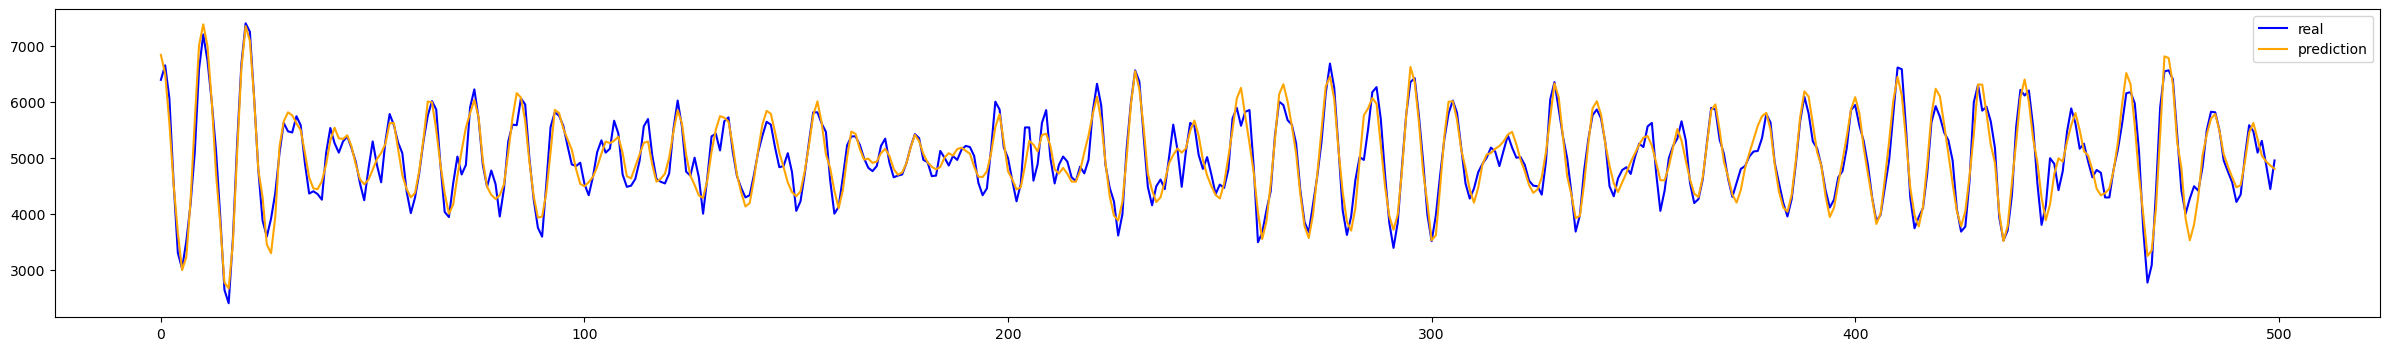

MAE: 191.50686230468747
MAE(sklearn): 191.50686230468747
MAPE(sklearn): 0.039360915979264346
MSE: 60008.91296112823
MSE(sklearn): 60008.91296112823
RMSE(sklearn): 244.96716710842747
Acc: 0.9925662881449813


In [22]:
# 反归一化并绘制Force1真实值vs预测值曲线
fan_force150_real1,fan_force150_pre1 = FanGuiHua_force1(valid50_y_Force1,N_pre50_Y_Force1)
# 保存结果到CSV文件（真实值+预测值），分隔符为逗号
np.savetxt('force150_步长1.csv',np.hstack((fan_force150_real1,fan_force150_pre1)),delimiter=',')

In [23]:
# 输入50步长输出1步长Force2
force250_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[350:,:], 4, 50)
force250_x1,force250_y1 = split_sequence(force250_scaled1, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [24]:
train_force250_x1, train_force250_y1, valid_force250_x1, valid_force250_y1 = split_train_valid(force250_x1,force250_y1, 6900, 7500, 8000)

train50_x_Force2, valid50_x_Force2 = np.hstack((pretrain_heave50_Y1, pretrain_surge50_Y1, pretrain_pitch50_Y1)), np.hstack((pre_heave50_Y1, pre_surge50_Y1, pre_pitch50_Y1))
train50_y_Force2, valid50_y_Force2 = train_force250_y1, valid_force250_y1

N_model50_Force2, N_history50_Force2, N_pre50_train_Y_Force2, N_pre50_Y_Force2 = Model_NN(train50_x_Force2, train50_y_Force2, valid50_x_Force2, valid50_y_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.0766 - val_loss: 0.0862 - 295ms/epoch - 98ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0798 - val_loss: 0.0496 - 25ms/epoch - 8ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0571 - val_loss: 0.0564 - 24ms/epoch - 8ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0582 - val_loss: 0.0485 - 25ms/epoch - 8ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0495 - val_loss: 0.0456 - 26ms/epoch - 9ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0480 - val_loss: 0.0466 - 24ms/epoch - 8ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0457 - val_loss: 0.0434 - 26ms/epoch - 9ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0408 - val_loss: 0.0473 - 25ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0405 - val_loss: 0.0465 - 25ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0386 - val_loss: 0.0495 - 27ms/epoch - 9ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0398 - val_loss: 0.0511 - 25ms/epoch - 8ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0393 - val_loss: 0.0552 - 25ms/epoch - 8ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0401 - val_loss

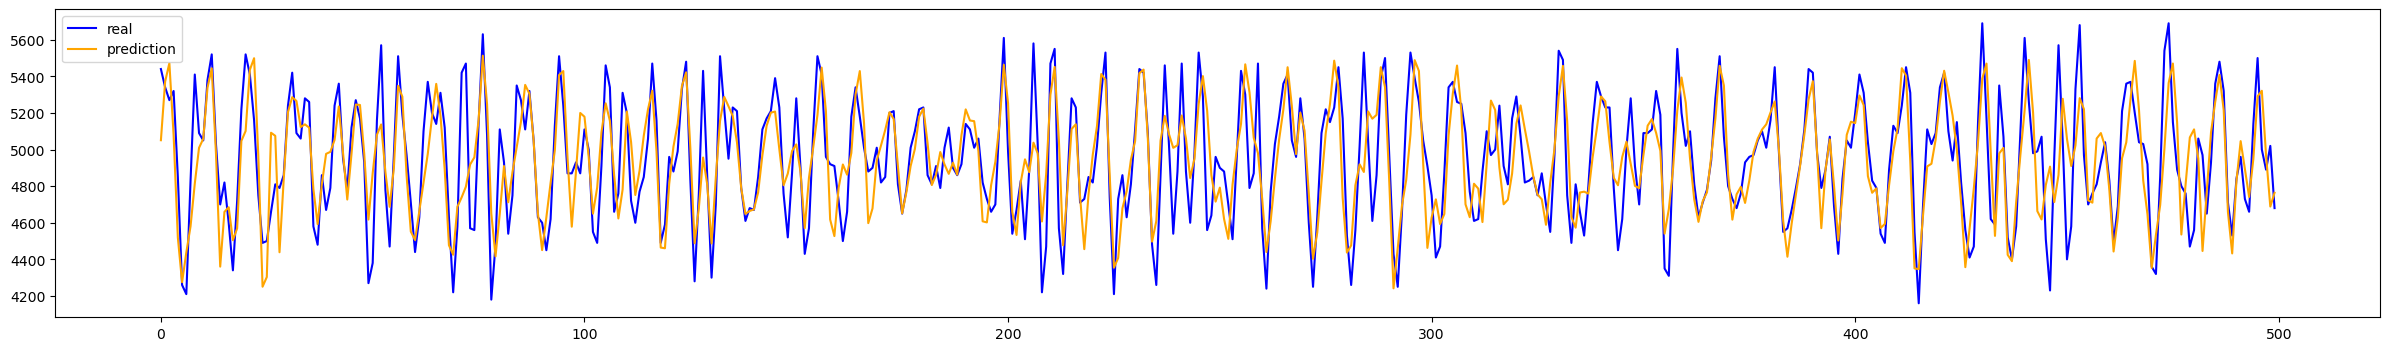

MAE: 173.458099609375
MAE(sklearn): 173.458099609375
MAPE(sklearn): 0.03525269000033586
MSE: 49164.506657049176
MSE(sklearn): 49164.506657049176
RMSE(sklearn): 221.7307075193898
Acc: 0.855901618523041


In [25]:
fan_force250_real1,fan_force250_pre1 = FanGuiHua_force2(valid50_y_Force2,N_pre50_Y_Force2)

np.savetxt('force250_步长1.csv',np.hstack((fan_force250_real1,fan_force250_pre1)),delimiter=',')

#### 系泊缆力联合预测（输入50步长，输出2步长）

In [26]:
# 未来运动预测模型建立
train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2 = split_train_valid(heave50_x2,heave50_y2, 6900, 7500, 8000)
heave50_model2, heave50_history2, pre_heave50_Y2 = Model_LSTM(train_heave50_x2, train_heave50_y2, valid_heave50_x2, valid_heave50_y2, lr=0.1, epochs=60, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2 = split_train_valid(surge50_x2,surge50_y2, 6600, 7500, 8000)
surge50_model2, surge50_history2, pre_surge50_Y2 = Model_LSTM(train_surge50_x2, train_surge50_y2, valid_surge50_x2, valid_surge50_y2, lr=1.3, epochs=60, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2 = split_train_valid(pitch50_x2,pitch50_y2, 6900, 7500, 8000)
pitch50_model2, pitch50_history2, pre_pitch50_Y2 = Model_LSTM(train_pitch50_x2, train_pitch50_y2, valid_pitch50_x2, valid_pitch50_y2, lr=0.35, epochs=60, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/60


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 3s - loss: 0.0627 - val_loss: 0.0764 - 3s/epoch - 222ms/step
Epoch 2/60
12/12 - 0s - loss: 0.0538 - val_loss: 0.0560 - 257ms/epoch - 21ms/step
Epoch 3/60
12/12 - 0s - loss: 0.0321 - val_loss: 0.0200 - 247ms/epoch - 21ms/step
Epoch 4/60
12/12 - 0s - loss: 0.0198 - val_loss: 0.0178 - 242ms/epoch - 20ms/step
Epoch 5/60
12/12 - 0s - loss: 0.0165 - val_loss: 0.0149 - 240ms/epoch - 20ms/step
Epoch 6/60
12/12 - 0s - loss: 0.0144 - val_loss: 0.0134 - 250ms/epoch - 21ms/step
Epoch 7/60
12/12 - 0s - loss: 0.0135 - val_loss: 0.0122 - 243ms/epoch - 20ms/step
Epoch 8/60
12/12 - 0s - loss: 0.0122 - val_loss: 0.0114 - 238ms/epoch - 20ms/step
Epoch 9/60
12/12 - 0s - loss: 0.0116 - val_loss: 0.0107 - 242ms/epoch - 20ms/step
Epoch 10/60
12/12 - 0s - loss: 0.0106 - val_loss: 0.0100 - 240ms/epoch - 20ms/step
Epoch 11/60
12/12 - 0s - loss: 0.0107 - val_loss: 0.0098 - 243ms/epoch - 20ms/step
Epoch 12/60
12/12 - 0s - loss: 0.0101 - val_loss: 0.0095 - 241ms/epoch - 20ms/step
Epoch 13/60
12/12 - 0s - l

In [27]:
pretrain_heave50_Y2 = heave50_model2.predict(train_heave50_x2)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y2 = surge50_model2.predict(train_surge50_x2[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y2 = pitch50_model2.predict(train_pitch50_x2)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y2.shape)
print(pretrain_surge50_Y2.shape)
print(pretrain_pitch50_Y2.shape)

19/19 [==============================] - 0s 6ms/step
(600, 1)
(600, 1)
(600, 1)


In [28]:
# 输入50步长输出2步长Force1
force150_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[349:,:], 4, 51)
force150_x2,force150_y2 = split_sequence(force150_scaled2, 50)
print(force150_x2.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [29]:
train_force150_x2, train_force150_y2, valid_force150_x2, valid_force150_y2 = split_train_valid(force150_x2,force150_y2, 6900, 7500, 8000)

train50_x2_Force1, valid50_x2_Force1 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force1, valid50_y2_Force1 = train_force150_y2, valid_force150_y2

N_model50_2_Force1, N_history50_2_Force1, N_pre50_train_Y2_Force1, N_pre50_Y2_Force1 = Model_NN(train50_x2_Force1, train50_y2_Force1, valid50_x2_Force1, valid50_y2_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0527 - val_loss: 0.0175 - 249ms/epoch - 83ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0184 - val_loss: 0.0238 - 25ms/epoch - 8ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0194 - val_loss: 0.0169 - 21ms/epoch - 7ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0144 - val_loss: 0.0147 - 21ms/epoch - 7ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0124 - val_loss: 0.0137 - 25ms/epoch - 8ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0125 - val_loss: 0.0145 - 23ms/epoch - 8ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0128 - val_loss: 0.0123 - 24ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0108 - val_loss: 0.0111 - 24ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0102 - val_loss: 0.0124 - 25ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0111 - val_loss: 0.0121 - 26ms/epoch - 9ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0109 - val_loss: 0.0113 - 27ms/epoch - 9ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0103 - val_loss: 0.0112 - 26ms/epoch - 9ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.01

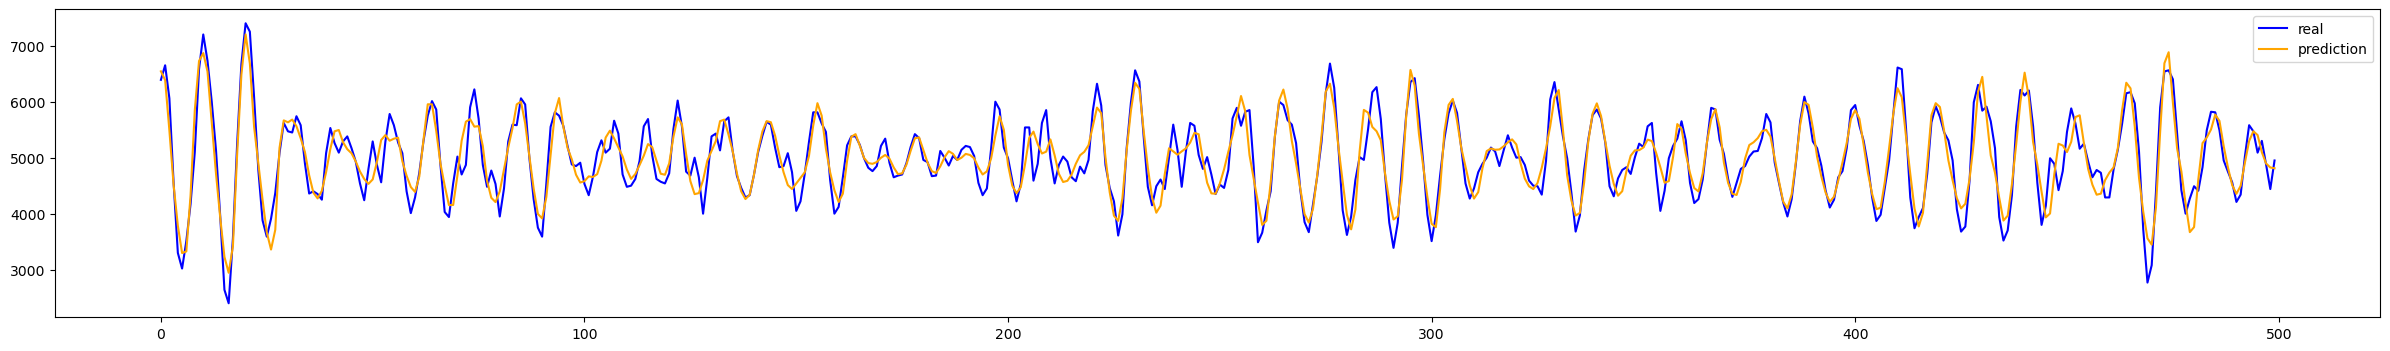

MAE: 236.849890625
MAE(sklearn): 236.849890625
MAPE(sklearn): 0.049139187924388525
MSE: 90525.2629728465
MSE(sklearn): 90525.2629728465
RMSE(sklearn): 300.87416468159324
Acc: 0.900495127608783


In [30]:
fan_force150_real2,fan_force150_pre2 = FanGuiHua_force1(valid50_y2_Force1,N_pre50_Y2_Force1)

np.savetxt('force150_步长2.csv',np.hstack((fan_force150_real2,fan_force150_pre2)),delimiter=',')

In [31]:
# 输入50步长输出2步长Force2
force250_scaled2 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[349:,:], 4, 51)
force250_x2,force250_y2 = split_sequence(force250_scaled2, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [32]:
train_force250_x2, train_force250_y2, valid_force250_x2, valid_force250_y2 = split_train_valid(force250_x2,force250_y2, 6900, 7500, 8000)

train50_x2_Force2, valid50_x2_Force2 = np.hstack((pretrain_heave50_Y2, pretrain_surge50_Y2, pretrain_pitch50_Y2)), np.hstack((pre_heave50_Y2, pre_surge50_Y2, pre_pitch50_Y2))
train50_y2_Force2, valid50_y2_Force2 = train_force250_y2, valid_force250_y2

N_model50_2_Force2, N_history50_2_Force2, N_pre50_train_Y2_Force2, N_pre50_Y2_Force2 = Model_NN(train50_x2_Force2, train50_y2_Force2, valid50_x2_Force2, valid50_y2_Force2,lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.1070 - val_loss: 0.0635 - 254ms/epoch - 85ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0744 - val_loss: 0.0708 - 25ms/epoch - 8ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0709 - val_loss: 0.0517 - 25ms/epoch - 8ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0580 - val_loss: 0.0549 - 22ms/epoch - 7ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0580 - val_loss: 0.0538 - 26ms/epoch - 9ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0534 - val_loss: 0.0486 - 24ms/epoch - 8ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0486 - val_loss: 0.0522 - 25ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0497 - val_loss: 0.0526 - 24ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0471 - val_loss: 0.0549 - 23ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0465 - val_loss: 0.0603 - 25ms/epoch - 8ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0474 - val_loss: 0.0597 - 26ms/epoch - 9ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0469 - val_loss: 0.0606 - 28ms/epoch - 9ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0478 - val_loss

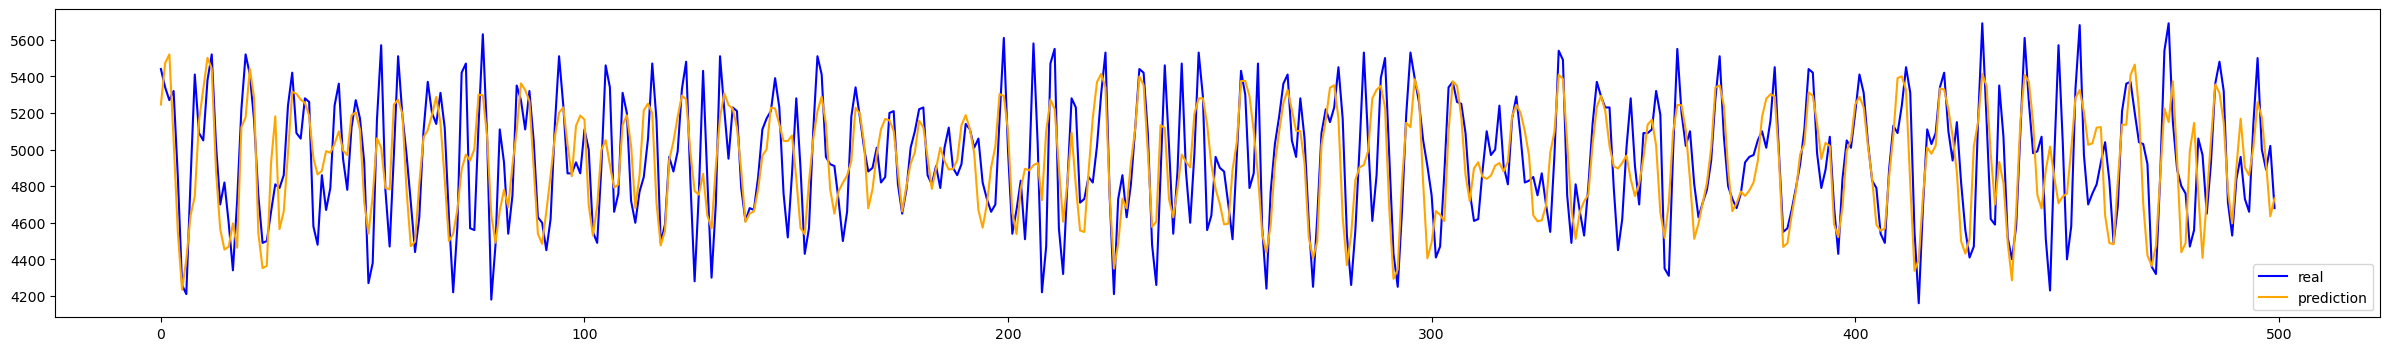

MAE: 185.465439453125
MAE(sklearn): 185.465439453125
MAPE(sklearn): 0.03770470407732691
MSE: 56305.95318515778
MSE(sklearn): 56305.95318515778
RMSE(sklearn): 237.2887548645274
Acc: 0.853760701645512


In [33]:
fan_force250_real2,fan_force250_pre2 = FanGuiHua_force2(valid50_y2_Force2,N_pre50_Y2_Force2)

np.savetxt('force250_步长2.csv',np.hstack((fan_force250_real2,fan_force250_pre2)),delimiter=',')

#### 系泊缆力联合预测（输入50步长，输出3步长）

In [34]:
# 未来运动预测模型建立
train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3 = split_train_valid(heave50_x3,heave50_y3, 6900, 7500, 8000)
heave50_model3, heave50_history3, pre_heave50_Y3 = Model_LSTM(train_heave50_x3, train_heave50_y3, valid_heave50_x3, valid_heave50_y3, lr=0.1, epochs=60, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3 = split_train_valid(surge50_x3,surge50_y3, 6600, 7500, 8000)
surge50_model3, surge50_history3, pre_surge50_Y3 = Model_LSTM(train_surge50_x3, train_surge50_y3, valid_surge50_x3, valid_surge50_y3, lr=1.3, epochs=60, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3 = split_train_valid(pitch50_x3,pitch50_y3, 6900, 7500, 8000)
pitch50_model3, pitch50_history3, pre_pitch50_Y3 = Model_LSTM(train_pitch50_x3, train_pitch50_y3, valid_pitch50_x3, valid_pitch50_y3, lr=0.35, epochs=60, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/60


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 3s - loss: 0.0639 - val_loss: 0.0815 - 3s/epoch - 209ms/step
Epoch 2/60
12/12 - 0s - loss: 0.0608 - val_loss: 0.0745 - 260ms/epoch - 22ms/step
Epoch 3/60
12/12 - 0s - loss: 0.0530 - val_loss: 0.0506 - 243ms/epoch - 20ms/step
Epoch 4/60
12/12 - 0s - loss: 0.0318 - val_loss: 0.0289 - 243ms/epoch - 20ms/step
Epoch 5/60
12/12 - 0s - loss: 0.0260 - val_loss: 0.0263 - 255ms/epoch - 21ms/step
Epoch 6/60
12/12 - 0s - loss: 0.0244 - val_loss: 0.0225 - 244ms/epoch - 20ms/step
Epoch 7/60
12/12 - 0s - loss: 0.0218 - val_loss: 0.0215 - 247ms/epoch - 21ms/step
Epoch 8/60
12/12 - 0s - loss: 0.0206 - val_loss: 0.0203 - 239ms/epoch - 20ms/step
Epoch 9/60
12/12 - 0s - loss: 0.0192 - val_loss: 0.0189 - 242ms/epoch - 20ms/step
Epoch 10/60
12/12 - 0s - loss: 0.0187 - val_loss: 0.0183 - 243ms/epoch - 20ms/step
Epoch 11/60
12/12 - 0s - loss: 0.0182 - val_loss: 0.0176 - 248ms/epoch - 21ms/step
Epoch 12/60
12/12 - 0s - loss: 0.0174 - val_loss: 0.0164 - 241ms/epoch - 20ms/step
Epoch 13/60
12/12 - 0s - l

In [35]:
pretrain_heave50_Y3 = heave50_model3.predict(train_heave50_x3)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y3 = surge50_model3.predict(train_surge50_x3[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y3 = pitch50_model3.predict(train_pitch50_x3)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y3.shape)
print(pretrain_surge50_Y3.shape)
print(pretrain_pitch50_Y3.shape)

19/19 [==============================] - 0s 6ms/step
(600, 1)
(600, 1)
(600, 1)


In [36]:
# 输入50步长输出3步长Force1
force150_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[348:,:], 4, 52)
force150_x3,force150_y3 = split_sequence(force150_scaled3, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [37]:
train_force150_x3, train_force150_y3, valid_force150_x3, valid_force150_y3 = split_train_valid(force150_x3,force150_y3, 6900, 7500, 8000)

train50_x3_Force1, valid50_x3_Force1 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force1, valid50_y3_Force1 = train_force150_y3, valid_force150_y3

N_model50_3_Force1, N_history50_3_Force1, N_pre50_train_Y3_Force1, N_pre50_Y3_Force1 = Model_NN(train50_x3_Force1, train50_y3_Force1, valid50_x3_Force1, valid50_y3_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0337 - val_loss: 0.0282 - 263ms/epoch - 88ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0266 - val_loss: 0.0166 - 26ms/epoch - 9ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0145 - val_loss: 0.0180 - 26ms/epoch - 9ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0165 - val_loss: 0.0212 - 25ms/epoch - 8ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0171 - val_loss: 0.0152 - 25ms/epoch - 8ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0135 - val_loss: 0.0143 - 22ms/epoch - 7ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0139 - val_loss: 0.0151 - 25ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0140 - val_loss: 0.0140 - 24ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0129 - val_loss: 0.0145 - 24ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0132 - val_loss: 0.0152 - 24ms/epoch - 8ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0135 - val_loss: 0.0145 - 23ms/epoch - 8ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0130 - val_loss: 0.0140 - 25ms/epoch - 8ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.01

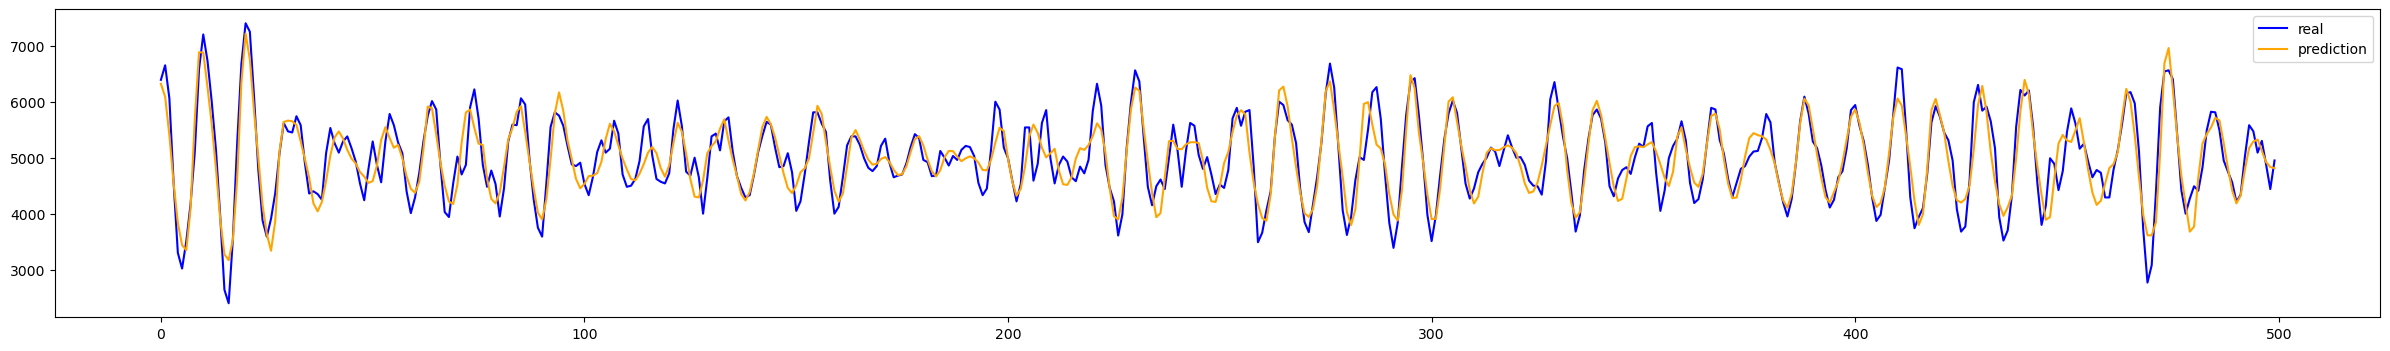

MAE: 263.879400390625
MAE(sklearn): 263.879400390625
MAPE(sklearn): 0.05464191503889245
MSE: 113144.81394742272
MSE(sklearn): 113144.81394742272
RMSE(sklearn): 336.3700550694469
Acc: 0.8979313853721247


In [38]:
fan_force150_real3,fan_force150_pre3 = FanGuiHua_force1(valid50_y3_Force1,N_pre50_Y3_Force1)

np.savetxt('force150_步长3.csv',np.hstack((fan_force150_real3,fan_force150_pre3)),delimiter=',')

In [39]:
# 输入50步长输出3步长Force2
force250_scaled3 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[348:,:], 4, 52)
force250_x3,force250_y3 = split_sequence(force250_scaled3, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [40]:
train_force250_x3, train_force250_y3, valid_force250_x3, valid_force250_y3 = split_train_valid(force250_x3,force250_y3, 6900, 7500, 8000)

train50_x3_Force2, valid50_x3_Force2 = np.hstack((pretrain_heave50_Y3, pretrain_surge50_Y3, pretrain_pitch50_Y3)), np.hstack((pre_heave50_Y3, pre_surge50_Y3, pre_pitch50_Y3))
train50_y3_Force2, valid50_y3_Force2 = train_force250_y3, valid_force250_y3

N_model50_3_Force2, N_history50_3_Force2, N_pre50_train_Y3_Force2, N_pre50_Y3_Force2 = Model_NN(train50_x3_Force2, train50_y3_Force2, valid50_x3_Force2, valid50_y3_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.0826 - val_loss: 0.0780 - 230ms/epoch - 77ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0781 - val_loss: 0.0531 - 23ms/epoch - 8ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0576 - val_loss: 0.0499 - 25ms/epoch - 8ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0542 - val_loss: 0.0485 - 24ms/epoch - 8ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0485 - val_loss: 0.0410 - 23ms/epoch - 8ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0426 - val_loss: 0.0447 - 23ms/epoch - 8ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0427 - val_loss: 0.0422 - 23ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0378 - val_loss: 0.0486 - 26ms/epoch - 9ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0382 - val_loss: 0.0510 - 24ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0377 - val_loss: 0.0514 - 23ms/epoch - 8ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0393 - val_loss: 0.0529 - 26ms/epoch - 9ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0386 - val_loss: 0.0543 - 27ms/epoch - 9ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0387 - val_loss

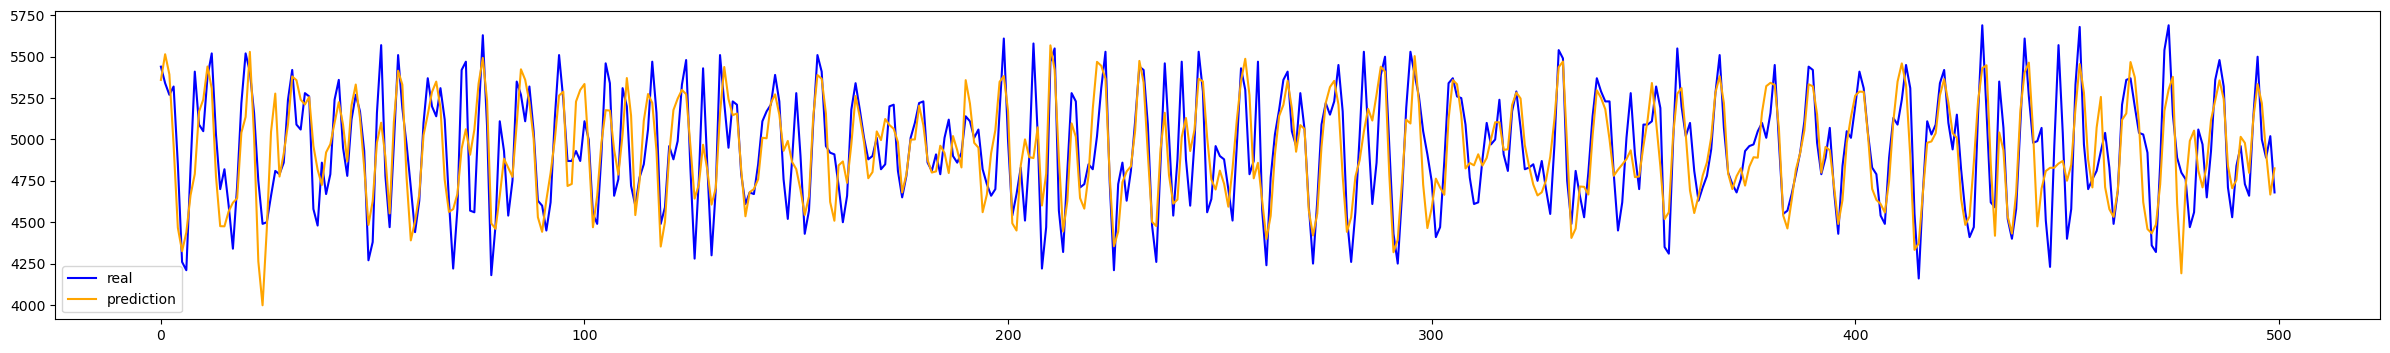

MAE: 171.21938623046876
MAE(sklearn): 171.21938623046876
MAPE(sklearn): 0.034801482535068845
MSE: 46915.55127406085
MSE(sklearn): 46915.55127406085
RMSE(sklearn): 216.59997985701855
Acc: 0.9044129617233928


In [41]:
fan_force250_real3,fan_force250_pre3 = FanGuiHua_force2(valid50_y3_Force2,N_pre50_Y3_Force2)

np.savetxt('force250_步长3.csv',np.hstack((fan_force250_real3,fan_force250_pre3)),delimiter=',')

#### 系泊缆力联合预测（输入50步长，输出4步长）

In [42]:
# 未来运动预测模型建立
train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4 = split_train_valid(heave50_x4,heave50_y4, 6900, 7500, 8000)
heave50_model4, heave50_history4, pre_heave50_Y4 = Model_LSTM(train_heave50_x4, train_heave50_y4, valid_heave50_x4, valid_heave50_y4, lr=0.1, epochs=60, batch_size=50)
# train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1 = split_train_valid(heave100_x1,heave100_y1, 6900, 7500, 8000)
# heave100_model1, heave100_history1, pre_heave100_Y1 = Model_LSTM(train_heave100_x1, train_heave100_y1, valid_heave100_x1, valid_heave100_y1, lr=0.1, epochs=60, batch_size=50)

train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4 = split_train_valid(surge50_x4,surge50_y4, 6600, 7500, 8000)
surge50_model4, surge50_history4, pre_surge50_Y4 = Model_LSTM(train_surge50_x4, train_surge50_y4, valid_surge50_x4, valid_surge50_y4, lr=1.3, epochs=60, batch_size=50)
# train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1 = split_train_valid(surge100_x1,surge100_y1, 6600, 7500, 8000)
# surge100_model1, surge100_history1, pre_surge100_Y1 = Model_LSTM(train_surge100_x1, train_surge100_y1, valid_surge100_x1, valid_surge100_y1, lr=1.3, epochs=60, batch_size=50)
                                                                 
train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4 = split_train_valid(pitch50_x4,pitch50_y4, 6900, 7500, 8000)
pitch50_model4, pitch50_history4, pre_pitch50_Y4 = Model_LSTM(train_pitch50_x4, train_pitch50_y4, valid_pitch50_x4, valid_pitch50_y4, lr=0.35, epochs=60, batch_size=50)
# train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1 = split_train_valid(pitch100_x1,pitch100_y1, 6900, 7500, 8000)
# pitch100_model1, pitch100_history1, pre_pitch100_Y1 = Model_LSTM(train_pitch100_x1, train_pitch100_y1, valid_pitch100_x1, valid_pitch100_y1, lr=0.35, epochs=60, batch_size=50)

Epoch 1/60


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


12/12 - 3s - loss: 0.0635 - val_loss: 0.0805 - 3s/epoch - 236ms/step
Epoch 2/60
12/12 - 0s - loss: 0.0595 - val_loss: 0.0684 - 271ms/epoch - 23ms/step
Epoch 3/60
12/12 - 0s - loss: 0.0448 - val_loss: 0.0303 - 241ms/epoch - 20ms/step
Epoch 4/60
12/12 - 0s - loss: 0.0289 - val_loss: 0.0276 - 247ms/epoch - 21ms/step
Epoch 5/60
12/12 - 0s - loss: 0.0276 - val_loss: 0.0248 - 242ms/epoch - 20ms/step
Epoch 6/60
12/12 - 0s - loss: 0.0270 - val_loss: 0.0245 - 241ms/epoch - 20ms/step
Epoch 7/60
12/12 - 0s - loss: 0.0251 - val_loss: 0.0241 - 241ms/epoch - 20ms/step
Epoch 8/60
12/12 - 0s - loss: 0.0242 - val_loss: 0.0234 - 246ms/epoch - 20ms/step
Epoch 9/60
12/12 - 0s - loss: 0.0239 - val_loss: 0.0238 - 241ms/epoch - 20ms/step
Epoch 10/60
12/12 - 0s - loss: 0.0237 - val_loss: 0.0225 - 246ms/epoch - 21ms/step
Epoch 11/60
12/12 - 0s - loss: 0.0228 - val_loss: 0.0222 - 247ms/epoch - 21ms/step
Epoch 12/60
12/12 - 0s - loss: 0.0227 - val_loss: 0.0216 - 258ms/epoch - 22ms/step
Epoch 13/60
12/12 - 0s - l

In [43]:
pretrain_heave50_Y4 = heave50_model4.predict(train_heave50_x4)
# pretrain_heave100_Y1 = heave100_model1.predict(train_heave100_x1)

pretrain_surge50_Y4 = surge50_model4.predict(train_surge50_x4[300:,:])
# pretrain_surge100_Y1 = surge100_model1.predict(train_surge100_x1)

pretrain_pitch50_Y4 = pitch50_model4.predict(train_pitch50_x4)
# pretrain_pitch100_Y1 = pitch100_model1.predict(train_pitch100_x1)
print(pretrain_heave50_Y4.shape)
print(pretrain_surge50_Y4.shape)
print(pretrain_pitch50_Y4.shape)

19/19 [==============================] - 0s 6ms/step
(600, 1)
(600, 1)
(600, 1)


In [44]:
# 输入50步长输出4步长Force1
force150_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[347:,:], 4, 53)
force150_x4,force150_y4 = split_sequence(force150_scaled4, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [45]:
train_force150_x4, train_force150_y4, valid_force150_x4, valid_force150_y4 = split_train_valid(force150_x4,force150_y4, 6900, 7500, 8000)

train50_x4_Force1, valid50_x4_Force1 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force1, valid50_y4_Force1 = train_force150_y4, valid_force150_y4

N_model50_4_Force1, N_history50_4_Force1, N_pre50_train_Y4_Force1, N_pre50_Y4_Force1 = Model_NN(train50_x4_Force1, train50_y4_Force1, valid50_x4_Force1, valid50_y4_Force1, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000
3/3 - 0s - loss: 0.0345 - val_loss: 0.0274 - 255ms/epoch - 85ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0256 - val_loss: 0.0195 - 25ms/epoch - 8ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0162 - val_loss: 0.0184 - 24ms/epoch - 8ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0162 - val_loss: 0.0211 - 23ms/epoch - 8ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0171 - val_loss: 0.0164 - 24ms/epoch - 8ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0145 - val_loss: 0.0152 - 24ms/epoch - 8ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0143 - val_loss: 0.0157 - 24ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0144 - val_loss: 0.0153 - 24ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0139 - val_loss: 0.0157 - 22ms/epoch - 7ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0139 - val_loss: 0.0158 - 24ms/epoch - 8ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0139 - val_loss: 0.0152 - 25ms/epoch - 8ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0137 - val_loss: 0.0148 - 24ms/epoch - 8ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.01

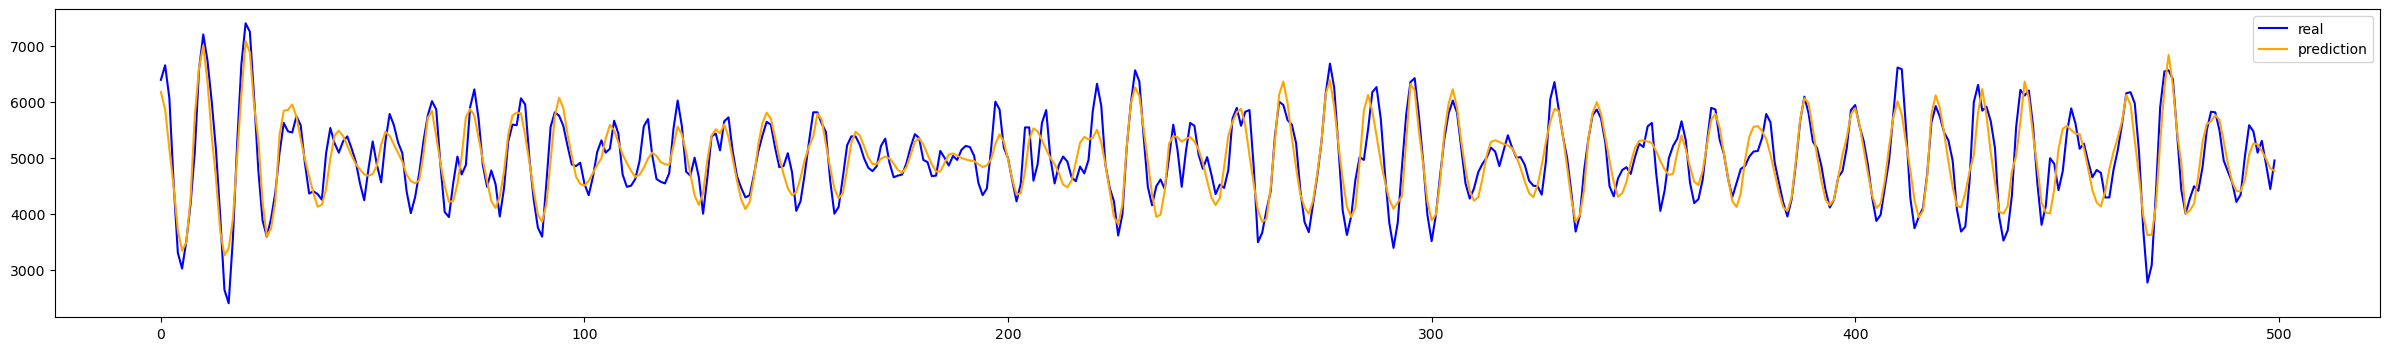

MAE: 272.300259765625
MAE(sklearn): 272.300259765625
MAPE(sklearn): 0.0561442530573633
MSE: 117397.53375142264
MSE(sklearn): 117397.53375142264
RMSE(sklearn): 342.6332350362741
Acc: 0.8926574051683804


In [46]:
fan_force150_real4,fan_force150_pre4 = FanGuiHua_force1(valid50_y4_Force1,N_pre50_Y4_Force1)

np.savetxt('force150_步长4.csv',np.hstack((fan_force150_real4,fan_force150_pre4)),delimiter=',')

In [47]:
# 输入50步长输出4步长Force2
force250_scaled4 = deal_data2(np.hstack((Heave,Surge,Pitch,Force2))[347:,:], 4, 53)
force250_x4,force250_y4 = split_sequence(force250_scaled4, 50)
print(force150_x1.shape)
# 输入100步长输出1步长
# force1100_scaled1 = deal_data2(np.hstack((Heave,Surge,Pitch,Force1))[300:,:], 4, 100)
# force1100_x1,force1100_y1 = split_sequence(force1100_scaled1, 100)
# print(force1100_x1.shape)

(10551, 50, 3)


In [48]:
train_force250_x4, train_force250_y4, valid_force250_x4, valid_force250_y4 = split_train_valid(force250_x4,force250_y4, 6900, 7500, 8000)

train50_x4_Force2, valid50_x4_Force2 = np.hstack((pretrain_heave50_Y4, pretrain_surge50_Y4, pretrain_pitch50_Y4)), np.hstack((pre_heave50_Y4, pre_surge50_Y4, pre_pitch50_Y4))
train50_y4_Force2, valid50_y4_Force2 = train_force250_y4, valid_force250_y4

N_model50_4_Force2, N_history50_4_Force2, N_pre50_train_Y4_Force2, N_pre50_Y4_Force2 = Model_NN(train50_x4_Force2, train50_y4_Force2, valid50_x4_Force2, valid50_y4_Force2, lr=0.01, epochs=1000, batch_size=256)

Epoch 1/1000


e:\anaconda\envs\predict_w\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


3/3 - 0s - loss: 0.1089 - val_loss: 0.0883 - 284ms/epoch - 95ms/step
Epoch 2/1000
3/3 - 0s - loss: 0.0978 - val_loss: 0.0760 - 25ms/epoch - 8ms/step
Epoch 3/1000
3/3 - 0s - loss: 0.0849 - val_loss: 0.0743 - 26ms/epoch - 9ms/step
Epoch 4/1000
3/3 - 0s - loss: 0.0832 - val_loss: 0.0777 - 24ms/epoch - 8ms/step
Epoch 5/1000
3/3 - 0s - loss: 0.0835 - val_loss: 0.0719 - 25ms/epoch - 8ms/step
Epoch 6/1000
3/3 - 0s - loss: 0.0794 - val_loss: 0.0702 - 29ms/epoch - 10ms/step
Epoch 7/1000
3/3 - 0s - loss: 0.0793 - val_loss: 0.0713 - 24ms/epoch - 8ms/step
Epoch 8/1000
3/3 - 0s - loss: 0.0793 - val_loss: 0.0700 - 25ms/epoch - 8ms/step
Epoch 9/1000
3/3 - 0s - loss: 0.0775 - val_loss: 0.0707 - 25ms/epoch - 8ms/step
Epoch 10/1000
3/3 - 0s - loss: 0.0769 - val_loss: 0.0718 - 23ms/epoch - 8ms/step
Epoch 11/1000
3/3 - 0s - loss: 0.0766 - val_loss: 0.0709 - 26ms/epoch - 9ms/step
Epoch 12/1000
3/3 - 0s - loss: 0.0756 - val_loss: 0.0710 - 26ms/epoch - 9ms/step
Epoch 13/1000
3/3 - 0s - loss: 0.0756 - val_los

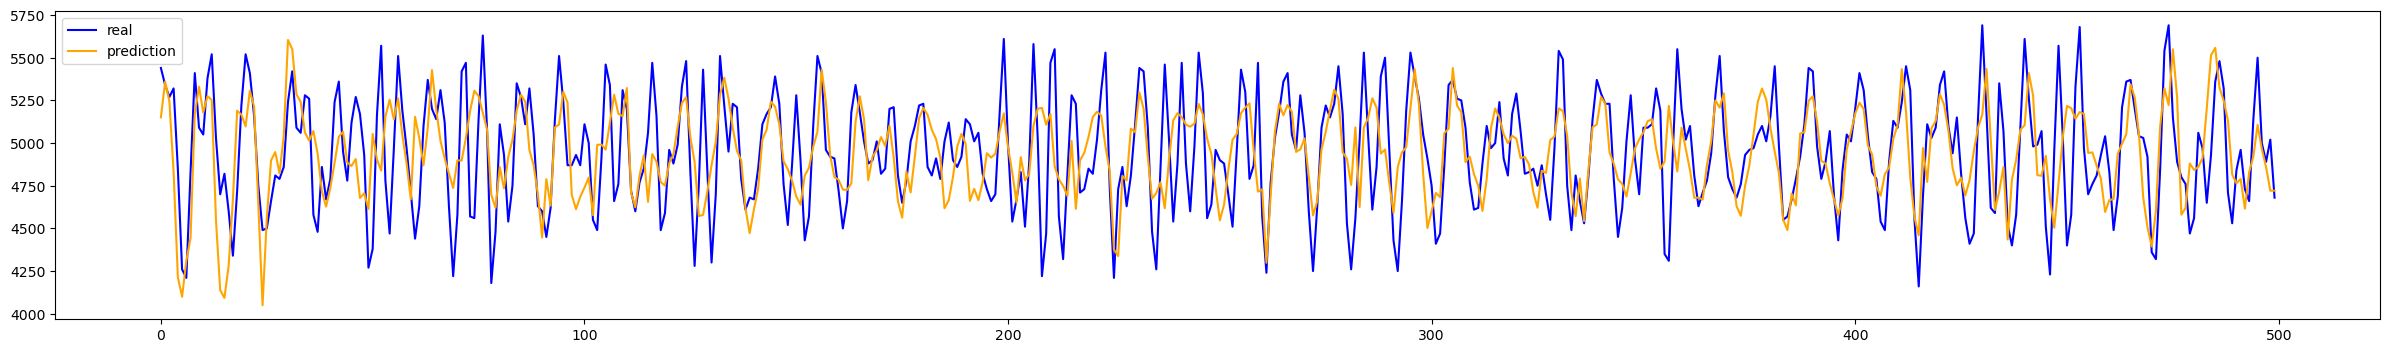

MAE: 233.0846181640625
MAE(sklearn): 233.0846181640625
MAPE(sklearn): 0.04750607077465746
MSE: 87378.85908801436
MSE(sklearn): 87378.85908801436
RMSE(sklearn): 295.59915271870176
Acc: 0.7440712197860395


In [49]:
fan_force250_real4,fan_force250_pre4 = FanGuiHua_force2(valid50_y4_Force2,N_pre50_Y4_Force2)

np.savetxt('force250_步长4.csv',np.hstack((fan_force250_real4,fan_force250_pre4)),delimiter=',')